Cauã Benini da Silva (RA )

Universidade Federal de São Carlos (UFSCar)

# Trabalho de Conclusão de Curso (TCC) - Aplicação dos Modelos


# Introdução

O objetivo deste trabalho é prever casos de hipotensão intradiálica em pacientes renais crônicos e posteriormente, adaptar estes modelos para uma plataforma web a fim de simular sessões de hemodiálise em Real Time.

Este trabalho se baseou no artigo *Predicting the Appearance of Hypotension during Hemodialysis Sessions Using Machine Learning Classifiers* (https://www.mdpi.com/1660-4601/18/5/2364#Abstract).

Abaixo, segue a importação das bibliotecas necessárias para esse desenvolvimento.

# Seleção do Dataset

Utilizou-se o dataset [*Dialysis database: sessions with valid data of clinical parameters*](https://data.mendeley.com/datasets/7kmtsmsgfw/1), disponibilizada pelos autores do artigo citado.

Este conjunto de dados foi coletado no Hospital Príncipe de Asturias (Madrid, Espanha) entre os anos de 2016 e 2019, abrangendo informações clínicas de 758 pacientes submetidos a tratamento de hemodiálise.

O dataset original contém aproximadamente 98.015 medições em sessões de hemodiálise, cada uma re-gistrada com até 22 parâmetros clínicos medidos em seis momentos distintos da sessão (Horas 0 a 5) - de forma com que cada 6 medições subsequentes correspondam a uma sessão de hemodiálise completa -, além de informações demográficas como idade e sexo dos pacientes. Entre
os parâmetros monitorados estão pressão arterial sistólica e diastólica, frequência cardíaca, peso pré e pós-diálise, volume de ultrafiltração, condutividade do banho de hemodiálise,
temperatura corporal, entre outros.

A identificação de episódios de hipotensão intradialítica foi realizada a partir da queda da pressão arterial sistólica maior ou igual a 20 mmHg entre os períodos iniciais e intermediários da sessão. Com base nesse critério, cerca de 25.026 sessões (aproximadamente 26% do total) apresentaram episódios de hipotensão, distribuídos entre 584 pacientes (77% da
amostra).


---

O autor forneceu 11 subcojuntos com múltiplas combinações de atributos válidos (cujas respectivas tuplas não possuem valores nulos ou com ouliers). Nesse caso, foi selecionado o subconjunto 7 da tabela a seguir, tendo em vista que os subconjuntos com mais atributos (8,9,10 e 11) apresentaram inconsistências em relação ao descrito pelo autor do dataset.

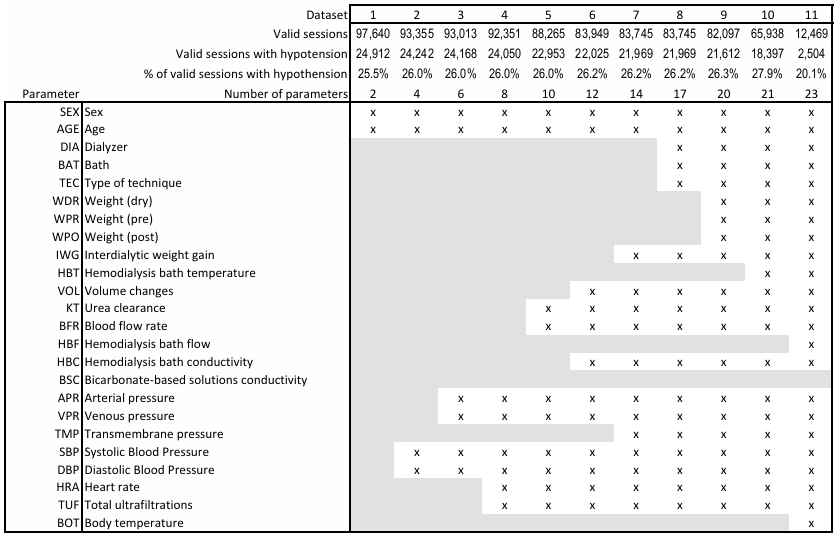

In [21]:
# Realizar download do Dataset do Drive
!pip install gdown pandas scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import gdown

url = 'https://drive.google.com/uc?id=150jgnqblZ4yIRKvMP8vixDoZE3GPPEqA'
output = 'data/dataset.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=150jgnqblZ4yIRKvMP8vixDoZE3GPPEqA
To: c:\Users\cauab\OneDrive\Área de Trabalho\TCC\data\dataset.csv
100%|██████████| 17.3M/17.3M [00:00<00:00, 27.1MB/s]


'data/dataset.csv'

In [23]:
# Transformar em Dataframe do Pandas e printar
import pandas as pd

df = pd.read_csv('data/dataset.csv', sep=";", index_col=False)
df

,D_Hipotension,D_Sexo,D_Edad,D_Dializador,D_Bano,D_Tecnica,D_PesoSeco,D_PesoPre,D_PesoPost,D_Ganancia,...,D_ConductividadBano,D_ConductividadBicarbonato,D_PresionArterial,D_PresionVenosa,D_PTM,D_TAS,D_TAD,D_Pulso,D_UF,D_Temperatura
0,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
1,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.7,0.0,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
2,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
3,NO,1,69,8,1,1,69.0,70.0,68.6,1.0,...,13.7,0.0,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3
4,NO,1,69,8,1,1,69.0,70.0,69.0,1.2,...,13.7,0.0,-170.0,155.0,175.0,131.0,58.0,62.0,0.08,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,NO,1,82,1,15,0,71.0,73.3,70.9,1.9,...,13.3,0.0,-200.0,170.0,20.0,155.0,78.0,82.0,0.70,0.0
83741,NO,1,82,1,15,0,71.0,73.0,70.9,2.1,...,14.0,0.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59,0.0
83742,NO,1,82,1,15,0,71.0,73.7,71.1,2.8,...,13.7,0.0,-230.0,140.0,25.0,150.0,67.0,70.0,0.74,0.0
83743,NO,1,82,1,15,0,71.0,72.8,71.0,1.7,...,13.7,0.0,-200.0,155.0,15.0,129.0,60.0,83.0,0.51,0.0


# Preparação do Dataset

## 1. Tradução dos Atributos e Seleção dos Atributos Válidos

Para facilitar o entendimento, aplicou-se os mesmo nomes das colunas encontrados no artigo base neste dataset (já estavam na mesma ordem, apenas foram traduzidas para Espannhol).

Segue a tabela que mostra a descrição de cada um dos atributos:

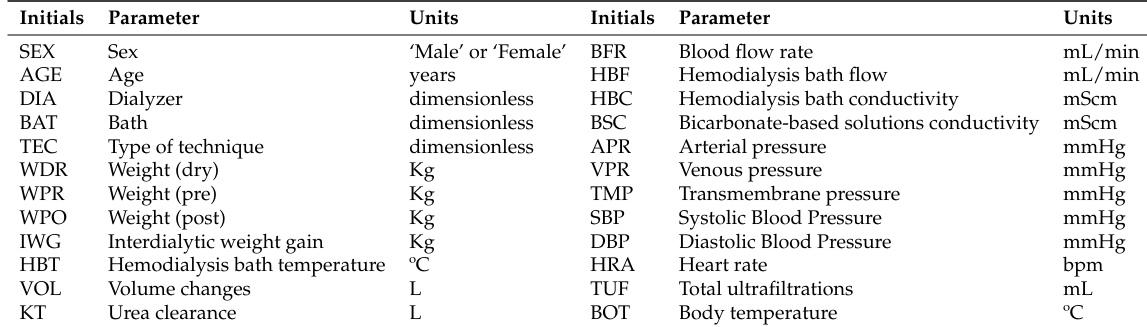


In [24]:
df.columns = ["Hypotension","SEX","AGE","DIA","BAT","TEC","WDR","WPR","WPO","IWG",
              "HBT","VOL","KT","BFR","HBF","HBC","BSC","APR","VPR","TMP",
              "SBP","DBP","HRA","TUF","BOT"]
df

,Hypotension,SEX,AGE,DIA,BAT,TEC,WDR,WPR,WPO,IWG,...,HBC,BSC,APR,VPR,TMP,SBP,DBP,HRA,TUF,BOT
0,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-100.0,80.0,150.0,146.0,46.0,72.0,0.10,37.1
1,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.7,0.0,-175.0,155.0,35.0,137.0,58.0,69.0,0.11,37.1
2,NO,1,69,8,1,1,0.0,0.0,0.0,0.0,...,13.6,0.0,-170.0,155.0,200.0,153.0,67.0,68.0,0.09,37.4
3,NO,1,69,8,1,1,69.0,70.0,68.6,1.0,...,13.7,0.0,-155.0,120.0,185.0,138.0,55.0,68.0,0.10,37.3
4,NO,1,69,8,1,1,69.0,70.0,69.0,1.2,...,13.7,0.0,-170.0,155.0,175.0,131.0,58.0,62.0,0.08,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,NO,1,82,1,15,0,71.0,73.3,70.9,1.9,...,13.3,0.0,-200.0,170.0,20.0,155.0,78.0,82.0,0.70,0.0
83741,NO,1,82,1,15,0,71.0,73.0,70.9,2.1,...,14.0,0.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59,0.0
83742,NO,1,82,1,15,0,71.0,73.7,71.1,2.8,...,13.7,0.0,-230.0,140.0,25.0,150.0,67.0,70.0,0.74,0.0
83743,NO,1,82,1,15,0,71.0,72.8,71.0,1.7,...,13.7,0.0,-200.0,155.0,15.0,129.0,60.0,83.0,0.51,0.0


Em seguida, selecionou-se apenas os atributos válidos (sem valores nulos ou outliers), de acordo com a tabela da primeira seção.

In [25]:
colunas_validas = [
    'Hypotension', 'SEX', 'AGE',
    'IWG', 'VOL', 'KT', 'BFR',
    'HBC', 'APR', 'VPR',
    'TMP', 'SBP', 'DBP', 'HRA', 'TUF'
]
df = df[colunas_validas].copy()
df

,Hypotension,SEX,AGE,IWG,VOL,KT,BFR,HBC,APR,VPR,TMP,SBP,DBP,HRA,TUF
0,NO,1,69,0.0,42.81,41.7,250.0,13.6,-100.0,80.0,150.0,146.0,46.0,72.0,0.10
1,NO,1,69,0.0,25.95,65.9,400.0,13.7,-175.0,155.0,35.0,137.0,58.0,69.0,0.11
2,NO,1,69,0.0,25.21,63.1,400.0,13.6,-170.0,155.0,200.0,153.0,67.0,68.0,0.09
3,NO,1,69,1.0,26.17,62.7,360.0,13.7,-155.0,120.0,185.0,138.0,55.0,68.0,0.10
4,NO,1,69,1.2,28.03,65.9,400.0,13.7,-170.0,155.0,175.0,131.0,58.0,62.0,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,NO,1,82,1.9,0.00,55.3,460.0,13.3,-200.0,170.0,20.0,155.0,78.0,82.0,0.70
83741,NO,1,82,2.1,0.10,57.8,490.0,14.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59
83742,NO,1,82,2.8,0.00,53.0,450.0,13.7,-230.0,140.0,25.0,150.0,67.0,70.0,0.74
83743,NO,1,82,1.7,0.00,52.8,440.0,13.7,-200.0,155.0,15.0,129.0,60.0,83.0,0.51


Observação: Normalmente, não faria sentido variáveis como APR e VPR serem negativas. Contudo, no contexto da hemodiálise sim, pois elas indicam,

APR (Pressão arterial) - Pré-bomba:

* É medida no segmento do circuito que puxa sangue do paciente para a bomba.
* Como a bomba gera sucção, essa pressão costuma ser negativa em relação à atmosférica.

VPR (Pressão venosa) - Pós-filtro:
* É medida após o filtro, antes de o sangue retornar ao paciente.
* Aqui a bomba está empurrando o sangue, então a pressão é positiva.

## 2. Pré-Processamento

In [26]:
# 1. Limpeza dos dados
# ------------------------------------------------------------
# Padronizar Hypotension para maiúsculas
df['Hypotension'] = df['Hypotension'].str.upper()

# Mapear Hypotension: 'No' -> 0, 'Si' -> 1
#        SEX: 2 -> 1, 1 -> 0
df['Hypotension'] = df['Hypotension'].astype(str).str.strip()
df['Hypotension'] = df['Hypotension'].map({'NO':0,'SI':1})
df['SEX'] = df['SEX'].map({1:0,2:1})

# Converter SEX e AGE para inteiros
df['SEX'] = df['SEX'].astype(int)
df['AGE'] = df['AGE'].astype(int)

# Verificar distribuição original
print("Distribuição original de Hypotension:")
print(df['Hypotension'].value_counts())

Distribuição original de Hypotension:
Hypotension
0    61776
1    21969
Name: count, dtype: int64


In [27]:
df

,Hypotension,SEX,AGE,IWG,VOL,KT,BFR,HBC,APR,VPR,TMP,SBP,DBP,HRA,TUF
0,0,0,69,0.0,42.81,41.7,250.0,13.6,-100.0,80.0,150.0,146.0,46.0,72.0,0.10
1,0,0,69,0.0,25.95,65.9,400.0,13.7,-175.0,155.0,35.0,137.0,58.0,69.0,0.11
2,0,0,69,0.0,25.21,63.1,400.0,13.6,-170.0,155.0,200.0,153.0,67.0,68.0,0.09
3,0,0,69,1.0,26.17,62.7,360.0,13.7,-155.0,120.0,185.0,138.0,55.0,68.0,0.10
4,0,0,69,1.2,28.03,65.9,400.0,13.7,-170.0,155.0,175.0,131.0,58.0,62.0,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83740,0,0,82,1.9,0.00,55.3,460.0,13.3,-200.0,170.0,20.0,155.0,78.0,82.0,0.70
83741,0,0,82,2.1,0.10,57.8,490.0,14.0,-210.0,190.0,15.0,150.0,81.0,93.0,0.59
83742,0,0,82,2.8,0.00,53.0,450.0,13.7,-230.0,140.0,25.0,150.0,67.0,70.0,0.74
83743,0,0,82,1.7,0.00,52.8,440.0,13.7,-200.0,155.0,15.0,129.0,60.0,83.0,0.51


Como os pacientes estão anomalizados, criou-se um identificador único tendo em vista o sexo e a idade dos pacientes, haja visto que o autor do dataset descreve, em seu artigo, que esses são identificadores válidos.

In [28]:
# 2. Criar identificador de paciente (sexo + idade)
# ------------------------------------------------------------
# Criar identificador de paciente
df['patient_id'] = df['SEX'].astype(str) + '_' + df['AGE'].astype(str)

In [29]:
# 3. Preservar a ordem original e ordenar por paciente e ordem
# ------------------------------------------------------------
# Coluna de ordem original
df['order'] = range(len(df))

# Ordenar
df_sorted = df.sort_values(['patient_id', 'order']).reset_index(drop=True)

print(df.head())

   Hypotension  SEX  AGE  IWG    VOL    KT    BFR   HBC    APR    VPR    TMP  \
0            0    0   69  0.0  42.81  41.7  250.0  13.6 -100.0   80.0  150.0   
1            0    0   69  0.0  25.95  65.9  400.0  13.7 -175.0  155.0   35.0   
2            0    0   69  0.0  25.21  63.1  400.0  13.6 -170.0  155.0  200.0   
3            0    0   69  1.0  26.17  62.7  360.0  13.7 -155.0  120.0  185.0   
4            0    0   69  1.2  28.03  65.9  400.0  13.7 -170.0  155.0  175.0   

     SBP   DBP   HRA   TUF patient_id  order  
0  146.0  46.0  72.0  0.10       0_69      0  
1  137.0  58.0  69.0  0.11       0_69      1  
2  153.0  67.0  68.0  0.09       0_69      2  
3  138.0  55.0  68.0  0.10       0_69      3  
4  131.0  58.0  62.0  0.08       0_69      4  


Tendo em vista que cada 6 medições consecutivas equivalem a uma sessão de hemodiálise completa, nós iremos agrupar essas sessões por sessão individual de cada paciente (um paciente pode realizar mais de uma sessão).

Além disso, também já será gerado o novo Dataframe aplainado (flated) para posterior aplicação dos modelos.

In [30]:
# 4. Agrupar em sessões de 6 linhas consecutivas por paciente
# ------------------------------------------------------------
flat_rows = []

for pid, group in df_sorted.groupby('patient_id'):
    n_rows = len(group)
    n_sessions = n_rows // 6
    for i in range(n_sessions):
        start = i * 6
        session = group.iloc[start:start+6]
        flat_row = {}
        # Demográficos
        flat_row['SEX'] = session.iloc[0]['SEX']
        flat_row['AGE'] = session.iloc[0]['AGE']
        # Variáveis clínicas por hora
        for col in colunas_validas:
            if col in ['Hypotension', 'SEX', 'AGE', 'patient_id', 'order']:
                continue
            for hour in range(6):
                flat_row[f'{col}_H{hour}'] = session.iloc[hour][col]
        # Alvo: 1 se houver 'SI' (já em maiúsculas)
        target = 1 if (session['Hypotension'] == 1).any() else 0
        flat_row['Target'] = target
        flat_rows.append(flat_row)

df_flat = pd.DataFrame(flat_rows)
print(f"\nShape do dataset aplainado: {df_flat.shape}")
print("Distribuição do target:")
print(df_flat['Target'].value_counts())


Shape do dataset aplainado: (13895, 75)
Distribuição do target:
Target
1    9194
0    4701
Name: count, dtype: int64


In [31]:
df_flat

,SEX,AGE,IWG_H0,IWG_H1,IWG_H2,IWG_H3,IWG_H4,IWG_H5,VOL_H0,VOL_H1,...,HRA_H3,HRA_H4,HRA_H5,TUF_H0,TUF_H1,TUF_H2,TUF_H3,TUF_H4,TUF_H5,Target
0,0,19,0.0,0.0,0.0,0.6,1.0,-1.4,12.08,20.57,...,95.0,77.0,75.0,0.03,0.03,0.01,0.02,0.03,0.01,1
1,0,19,1.8,-0.2,-0.4,1.2,0.2,-0.8,26.11,24.49,...,88.0,110.0,102.0,0.20,0.03,0.05,0.02,0.02,0.03,1
2,0,19,-0.2,2.4,-0.2,2.0,-1.4,-1.6,29.61,22.69,...,88.0,110.0,112.0,0.07,0.02,0.02,0.02,0.00,0.03,1
3,0,19,0.6,0.0,0.0,2.2,0.4,-1.0,28.33,42.42,...,94.0,91.0,93.0,0.03,0.01,0.02,0.02,0.03,0.03,1
4,0,19,1.0,0.8,0.0,-0.6,0.8,1.0,29.20,26.93,...,99.0,83.0,81.0,0.03,0.03,0.03,0.02,0.01,0.07,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13890,1,97,0.9,0.3,1.0,0.4,0.8,0.4,0.00,0.00,...,83.0,62.0,63.0,0.15,0.13,0.32,0.34,0.34,0.16,0
13891,1,97,0.2,-0.1,0.9,0.0,-0.3,-0.3,0.00,0.00,...,88.0,69.0,50.0,0.44,0.07,0.21,0.07,0.00,0.06,1
13892,1,97,0.7,0.8,1.2,2.0,1.3,1.1,0.00,0.00,...,96.0,93.0,79.0,0.05,0.11,0.34,0.51,0.44,0.34,0
13893,1,97,0.5,0.7,1.5,1.3,0.6,-0.3,0.00,0.00,...,78.0,80.0,94.0,0.18,0.21,0.39,0.29,0.14,0.05,0


# Aplicação dos Modelos


## 1. Amostragem

O código abaixo ilustra a amostragem realizada para se ter um conjunto de treino e validação dos modelos. Nela, algumas escolhas foram feitas, considerando a natureza do dataset:

* **Amostragem holdout:** considerando que após todas operações de pré-processamento necessária restaram-se 13895 tuplas de dados no dataset, pode-se afirmar que existe uma quantidade de dados suficiente para que um bom treinamento e um bom conjunto de testes seja dividido para que se faça a validação dos dados contra overfit e má generalização. Além disso, o uso de cross-validation com tamanho dataset seria custoso, o que se evidenciaria com mais força com o posterior uso de técnicas de GridSearch para refino dos hiperparâmetros e aplicação de diferentes modelos. Assim, um holdout clássico simples com 80% dos dados para treino e 20% dos dados para validação foram usados.

* **Amostragem estratificada:** Outra escolha feita foi a estratificação dos dados com base na coluna y (*Target*). Isso foi feito considerando que existe um desequilíbrio entre a quantidade de tuplas pertencentes a cada uma das classes, sendo que os alvos com hipotensão intradiálica (*Target = 1*) representam 9194 objetos e aqueles sem hipotensão intradiálica ((*Target = 0*) são 4701. Dessa forma, a estratificação por tal coluna garante uma representação proporcional dos dados nos conjuntos de treino e teste, mantendo a essência da população e evitando viés.

In [32]:
from sklearn.model_selection import train_test_split

y = df_flat['Target']
X = df_flat.drop(columns=['Target'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

## 2. Metrificação de Desempenho

Antes da aplicação dos modelos, foi definida uma função para utilização padronizada das métricas de desempenho. Nele, foi decidido por usar 3 medidas:
* **Acurácia**: por oferecer uma perspectiva geral da performance do modelo, indicando a proporção de previsões corretas.
* **Precisão**: avaliação da confiabilidade das previsões positivas, cruvial quandos os custos de um falso positivo são altos (tal qual em casos clínicos).
* **F1-score**: combinação das métricas *Precisão* e *Recall*(proporção de positivos reais identificados corretamente) em uma única métrica, fornecendo um equilíbrio entre ambos.
* **AUC Score**: representa a área sob a curva ROC (Receiver Operating Characteristic), que avalia a capacidade do modelo em distinguir entre classes positivas e negativas em diferentes limiares de decisão. Um valor próximo de 1 indica excelente poder discriminativo, enquanto valores próximos de 0,5 sugerem desempenho equivalente ao acaso. Essa métrica é especialmente útil em cenários com classes desbalanceadas, pois fornece uma visão mais robusta da performance do modelo além das métricas tradicionais.

Além disso, foi exibida a matriz de confusão e a própria curva ROC para posteriores análise visuais e intuitivas do resultado.

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score
)

def evaluate(y_test, y_pred, y_scores, model_name):
    """
    Avalia um classificador binário.

    Parâmetros
    ----------
    y_test : array-like
        Rótulos verdadeiros (0/1).
    y_pred : array-like
        Previsões binárias (0/1).
    y_scores : array-like
        Scores contínuos por amostra (ex.: saída de decision_function ou
        probabilidades da classe positiva).
    model_name : str
        Nome do modelo (para títulos dos gráficos).

    Retorna
    -------
    tuple
        (accuracy, precision, f1_score, auc_score)
    """

    # Métricas de classificação
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1_sc = f1_score(y_test, y_pred)

    print(f'Classification Report for model {model_name}:\n\n', classification_report(y_test, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    cm_display = ConfusionMatrixDisplay(cm)
    cm_display.plot()
    plt.title(f'Confusion Matrix for model {model_name}')
    plt.show()

    print("----------------------------------------------------")

    # Curva ROC e AUC usando y_scores (pode ser decision_function ou probabilidades)
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc_score = roc_auc_score(y_test, y_scores)

    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], 'k--')  # linha diagonal
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for model {model_name}')
    plt.legend(loc='lower right')
    plt.show()

    return (acc, prec, f1_sc, auc_score)


In [34]:
# DF pra armazenar a acurácia de todos os modelos e depois comparar
result=pd.DataFrame(columns=['Model',
                             'Accuracy Score',
                             'Precision Score',
                             'F1-Score',
                             'AUC Score'] )

## 3. Algoritmos de Predição

Tendo em vista que utilizaremos múltiplos algoritmos de predição, há alguns cuidados específicos que podemos ter para obter melhores resultados.

#### Normalização
* **StandardScaler**: Utilizado para centralizar os dados em torno da média zero e desvio padrão igual a um. É indicado para algoritmos que assumem distribuição normal ou que são sensíveis à variância, como regressão logística, SVM e PCA. Essa normalização ajuda a evitar que variáveis com escalas diferentes dominem o processo de aprendizado.

* **MinMaxScaler**: Transforma os dados para um intervalo fixo, nesse caso, entre 0 e 1. É útil em algoritmos baseados em distância (como KNN) ou em redes neurais, onde valores em faixas controladas facilitam a convergência do treinamento. Preserva a distribuição original dos dados, mas garante que todos os atributos estejam na mesma escala.

#### Otimização de hiperparâmetros
* **GridSearchCV**: Outro fator a se considerar foi que a utilização do GridSearchCV, o qual testa exaustivamente diferentes modelos usando diferentes hiperparâmetros, utiliza internamente para comparação dos modelos a Cross-Validation com r folds definidos, de forma a retornar com mais confiabilidade um modelo bom, sem overfittings.

* **RandomizedSearchCV**: técnica de otimização de hiperparâmetros que busca aleatoriamente combinações de hiperparâmetros e avalia cada combinação usando validação cruzada. Ela é principalmente útil quando o espaço de busca é grande e a busca exaustiva (como GridSearchCV) é computacionalmente custosa.

In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.pipeline import Pipeline 

### 3.1 SVM (*Support Vector Machine)*:



O SVM foi utilizado como base de comparação para os demais método aplicados, tendo em vista que junto ao algortimo de Árvores de Decisão (Decision Tree) - apresentado posteriormente - foram os aplicados pelo autor em um dos artigos base.

Esse algoritmo busca separar as classes por meio de um hiperplano ótimo, maximizando a margem entre elas. Quando os dados não são linearmente separáveis, utiliza funções de kernel para projetá-los em espaços de maior dimensão, permitindo a classificação adequada. É reconhecido por sua robustez em cenários de alta dimensionalidade e por apresentar bom desempenho mesmo em datasets desbalanceados, especialmente quando associado a técnicas de normalização e ajuste de parâmetros.

#### SVM sem otimização de hiperparâmetros

Somente para fins didáticos, primeiro iremos realizar uma implementação do SVM sem otimização de hiperparâmetros e em sequência, com as devidas otimizações a fim de comparar as métricas de desempenho e o custo computacional.

In [36]:
from sklearn.svm import SVC

# --- Normalização padrão ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Treinar SVM ---
svm_classifier = SVC(random_state=42) 
svm_classifier.fit(X_train_scaled, y_train)

# Previsões binárias
y_pred = svm_classifier.predict(X_test_scaled)

# scores contínuos (margem)
y_scores = svm_classifier.decision_function(X_test_scaled)

Classification Report for model SVM:

               precision    recall  f1-score   support

           0       0.62      0.33      0.43       940
           1       0.72      0.90      0.80      1839

    accuracy                           0.70      2779
   macro avg       0.67      0.61      0.61      2779
weighted avg       0.69      0.70      0.67      2779



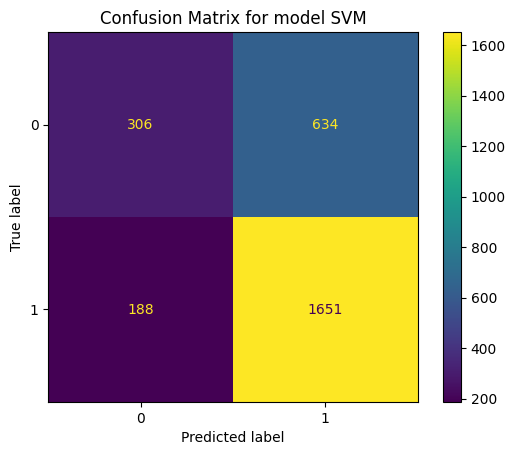

----------------------------------------------------


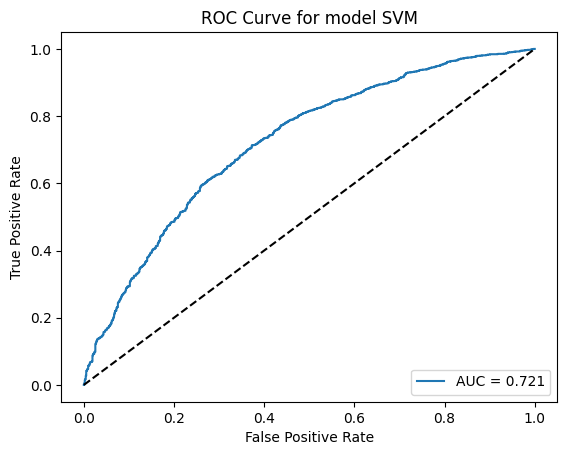

Accuracy: 0.7042101475350846
Precision: 0.7225382932166302
F1-Score: 0.8006789524733269
AUC: 0.7214767507780593


In [37]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'SVM')
result.loc[0] = ['SVM', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

In [38]:
print(f'O tamanho original teste é: {len(y_test)}')
print(f'O tamanho após o teste é: {len(y_pred)}')
print(f'\nO tamanho da amostra de treino é: {len(X_train_scaled)}')

O tamanho original teste é: 2779
O tamanho após o teste é: 2779

O tamanho da amostra de treino é: 11116


#### SVM com otimização de hiperparâmetros

Em seguida, utilizou-se RandomizedSearchCV por se utilizar de um modelo mais custoso. Dessa forma, espera-se que a classficação seja otimizada, pois ela foi utilizado dentro de um leque de parâmetros oferecidos pela documentação do projeto.

(Disponível em: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)


In [41]:
from sklearn.svm import SVC
from scipy.stats import loguniform

# --- Pipeline com normalização e SVM ---
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42, cache_size=1000, max_iter=100000))
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'svc' é o nome do passo do SVC dentro do pipeline

# 2. Espaço de Busca (prefixo 'svc__' para parâmetros do SVC dentro do pipeline)
param_dist = {
    'svc__C':      loguniform(1e-2, 1e2),           # potência: [0.01, 100]
    'svc__kernel': ['rbf', 'linear', 'poly'],
    'svc__gamma':  ['scale', 'auto'],               # ignorado pelo kernel linear
    'svc__degree': [2, 3, 4, 5],                    # só usado pelo kernel poly
}

# 3. Busca do melhor modelo
search_svm = RandomizedSearchCV(
    estimator           = pipe_svm,
    param_distributions = param_dist,
    n_iter              = 40,     # Número de combinações testadas
    cv                  = 5,      # Número de folds usados no Cross-Validation
    scoring             = ['accuracy','roc_auc'],
    refit               = 'roc_auc',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o scaler internamente)
search_svm.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_svm = search_svm.best_estimator_
print("Melhores hiperparâmetros (com prefixo do pipeline):", search_svm.best_params_)

# --- Avaliação ---
# Previsões e scores no conjunto de teste (passar X_test cru; pipeline aplicará scaler)
y_pred = best_svm.predict(X_test)
# Probabilidade da classe positiva 
y_scores = best_svm.decision_function(X_test)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Melhores hiperparâmetros (com prefixo do pipeline): {'svc__C': np.float64(1.211537999246959), 'svc__degree': 3, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}


Classification Report for model SVM otimizado:

               precision    recall  f1-score   support

           0       0.63      0.35      0.45       940
           1       0.73      0.89      0.80      1839

    accuracy                           0.71      2779
   macro avg       0.68      0.62      0.62      2779
weighted avg       0.69      0.71      0.68      2779



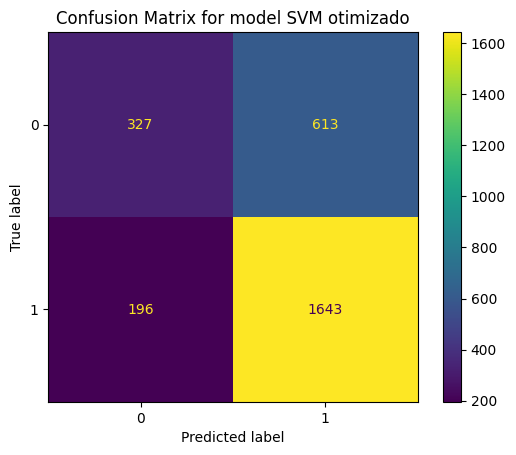

----------------------------------------------------


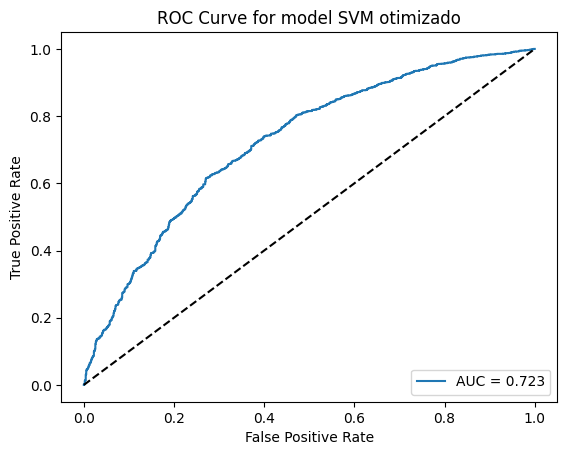

Accuracy: 0.7088880892407341
Precision: 0.7282801418439716
F1-Score: 0.8024420024420025
AUC: 0.7228980829081485


In [42]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'SVM otimizado')
result.loc[1] = ['SVM (otimizado)', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

### Decision Trees (Árvores de Decisão)

Assim como no método KNN, a árvore de decisão foi escolhido para esta tarefa com fins de comparação ao artigo base, bem como à sua simplicidade e interpretabilidade. As árvores de decisão são amplamente utilizadas em problemas de aprendizado supervisionado, pois oferecem uma forma clara de visualizar o processo de tomada de decisão do modelo. Elas funcionam dividindo recursivamente o espaço de características em regiões que maximizam a separação das classes (tendo em vista os métodos de avaliação de divisão), criando um modelo fácil de interpretar que pode lidar tanto com variáveis categóricas quanto contínuas.

Os dois métodos para avaliação de divisão das classes são:

* Gini: Mede a impureza de um nó. Um nó é puro se todas as amostras pertencem à mesma classe.
* Entropia (ou ganho de informação): Mede a quantidade de desordem ou imprevisibilidade em um nó

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# --- Pipeline com normalização e SVM ---
pipe_DT = Pipeline([
    # ('scaler', MinMaxScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# --- Treinamento do modelo ---
# 1. Declaração do modelo (já incluído no pipeline acima)
#    -> 'dt' é o nome do passo da DT dentro do pipeline

# 2. Espaço de Busca (prefixo 'dt__' para parâmetros do DT dentro do pipeline)
hyperparameters_DT = {
    'dt__max_depth': list(range(1, 20)),
    'dt__min_samples_split': list(range(2, 20)),
    'dt__min_samples_leaf': list(range(1, 20)),
    'dt__criterion': ['gini', 'entropy']
}

# 3. Busca do melhor modelo
DTree_classifier = RandomizedSearchCV(estimator=pipe_DT,
                                      param_distributions=hyperparameters_DT,
                                      n_iter        = 40,     # Número de combinações testadas
                                      cv            = 5,      # Número de folds usados no Cross-Validation
                                      scoring       = ['accuracy','roc_auc'],
                                      refit         = 'roc_auc',
                                      n_jobs        = -1,
                                      random_state  = 42,
                                      verbose       = 1
)

# 4. Treinamento do modelo (passar X_train cru; pipeline fará o scaler internamente)
DTree_classifier.fit(X_train, y_train)

# Melhor modelo (pipeline já treinado) e hiperparâmetros
best_estimator = DTree_classifier.best_estimator_
best_params = DTree_classifier.best_params_

print("Melhores parâmetros:", best_params)

# Avalia o desempenho do melhor modelo no conjunto de teste
y_pred = best_estimator.predict(X_test)
y_scores = best_estimator.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Melhores parâmetros: {'dt__min_samples_split': 15, 'dt__min_samples_leaf': 19, 'dt__max_depth': 6, 'dt__criterion': 'gini'}


Classification Report for model DT (otimizada):

               precision    recall  f1-score   support

           0       0.55      0.31      0.40       940
           1       0.71      0.87      0.78      1839

    accuracy                           0.68      2779
   macro avg       0.63      0.59      0.59      2779
weighted avg       0.66      0.68      0.65      2779



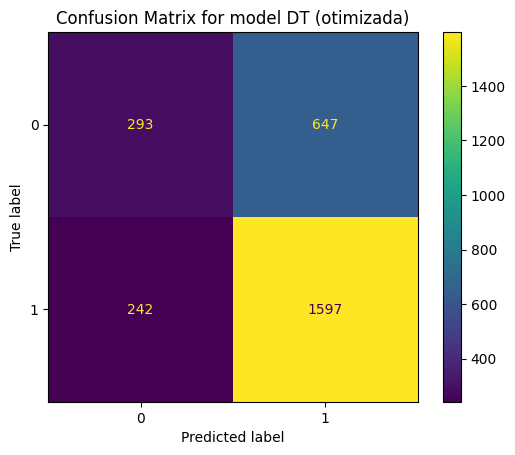

----------------------------------------------------


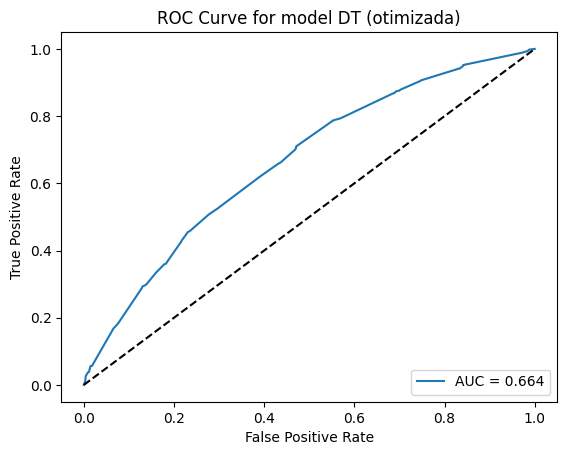

Accuracy: 0.6801007556675063
Precision: 0.7116755793226381
F1-Score: 0.7822679402400196
AUC: 0.663912510268069


In [44]:
# Validação do Modelo
acc, prec, f1_sc, auc_score = evaluate(y_test, y_pred, y_scores, 'DT (otimizada)')
result.loc[2] = ['DT (otimizada)', acc, prec, f1_sc, auc_score]

# Exibe métricas
print('Accuracy:', acc)
print('Precision:', prec)
print('F1-Score:', f1_sc)
print('AUC:', auc_score)

### Random Forests

### k-Nearest Neighbors (KNN)

### XGBoost (Extreme Gradient Boosting)

### Naive Bayes

### MLP (Multilayer Perceptron)

### Comparação das Métricas de Desempenho

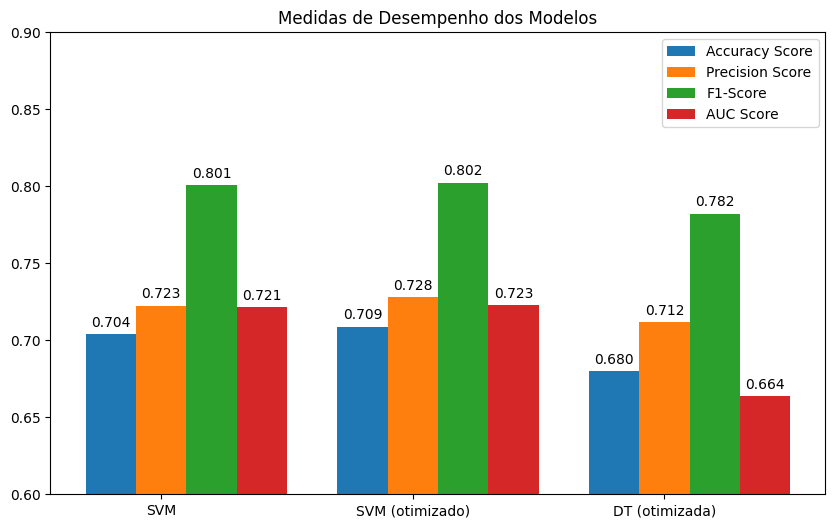

In [46]:
import numpy as np

# Configurações do gráfico
x = np.arange(len(result['Model']))  # posições no eixo x
width = 0.2  # largura das barras

# Criando a figura e os eixos
fig, ax = plt.subplots(figsize=(10, 6))

# Plotando as barras
bar1 = ax.bar(x - width, result['Accuracy Score'], width, label='Accuracy Score')
bar2 = ax.bar(x, result['Precision Score'], width, label='Precision Score')
bar3 = ax.bar(x + width, result['F1-Score'], width, label='F1-Score')
bar4 = ax.bar(x + 2*width, result['AUC Score'], width, label='AUC Score')

# Adicionando os valores nas barras
ax.bar_label(bar1, padding=3, fmt='%.3f')
ax.bar_label(bar2, padding=3, fmt='%.3f')
ax.bar_label(bar3, padding=3, fmt='%.3f')
ax.bar_label(bar4, padding=3, fmt='%.3f')

# Configurando o limite do eixo y
ax.set_ylim(0.6, 0.9)

# Adicionando os rótulos e título
ax.set_title('Medidas de Desempenho dos Modelos')
ax.set_xticks(x)
ax.set_xticklabels(result['Model'])
ax.legend()

# Exibindo o gráfico
plt.show()